<a href="https://colab.research.google.com/github/AuntBawHein/Car_Rental_Management_System_SQL_project/blob/main/Copy_of_ai_sentiment_notebook_analysis_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install textblob

# Import the the libraries
# Pandas used for cleaning and manipulating datas
import pandas as pd

# TextBlob primarily used for processing, cleaning, and analyzing textual data
# (NLP)
from textblob import TextBlob

# Load the dataset
df = pd.read_csv("student_reflections_150.csv")
df.head(20)

,id,student_level,reflection_text
0,1,M1,I feel happy when I study with my friends.
1,2,M2,Homework sometimes stresses me.
2,3,M3,I did my homework and rested.
3,4,M1,I feel motivated when teachers encourage me.
4,5,M2,Exams make me nervous.
5,6,M3,My day was okay.
6,7,M1,Learning new things makes me excited.
7,8,M2,I get worried when tests come close.
8,9,M3,School today was normal.
9,10,M1,I enjoy group work in class.


In [ ]:
def get_sent(text):
  score = TextBlob(text).sentiment.polarity
  if score > 0:
    return "positive"
  elif score < 0:
    return "Negative"
  else:
    return "Neutral"
df["sentiment"] = df["reflection_text"].apply(get_sent)
df.head(40)


,id,student_level,reflection_text,sentiment
0,1,M1,I feel happy when I study with my friends.,positive
1,2,M2,Homework sometimes stresses me.,Neutral
2,3,M3,I did my homework and rested.,Neutral
3,4,M1,I feel motivated when teachers encourage me.,Neutral
4,5,M2,Exams make me nervous.,Neutral
5,6,M3,My day was okay.,positive
6,7,M1,Learning new things makes me excited.,positive
7,8,M2,I get worried when tests come close.,Neutral
8,9,M3,School today was normal.,positive
9,10,M1,I enjoy group work in class.,positive


<Axes: xlabel='sentiment'>

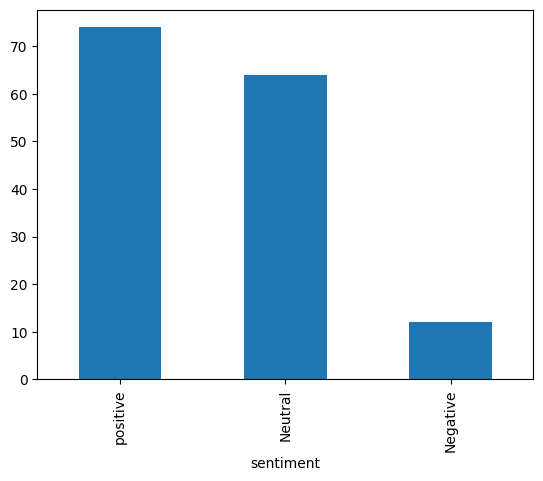

In [ ]:
df["sentiment"].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

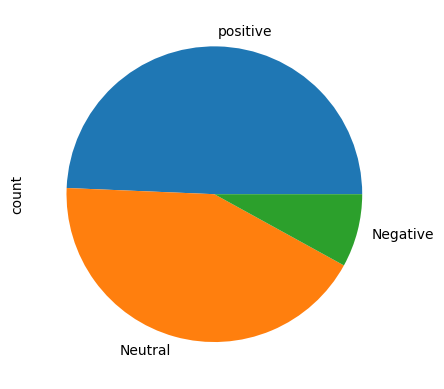

In [ ]:
df["sentiment"].value_counts().plot(kind='pie')

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,74
Neutral,64
Negative,12


In [ ]:
!pip install textblob wordcloud

import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from wordcloud import WordCloud

df = pd.read_csv("student_reflections_150.csv")

def get_sent(text):
  score = TextBlob(text).sentiment.polarity
  if score > 0:
    return "Positive"
  elif score < 0:
    return "Negative"
  else:
    return "Neutral"

df["sentiment"] = df["reflection_text"].apply(get_sent)

# Summary
df["sentiment"].value_counts()
plt.show()

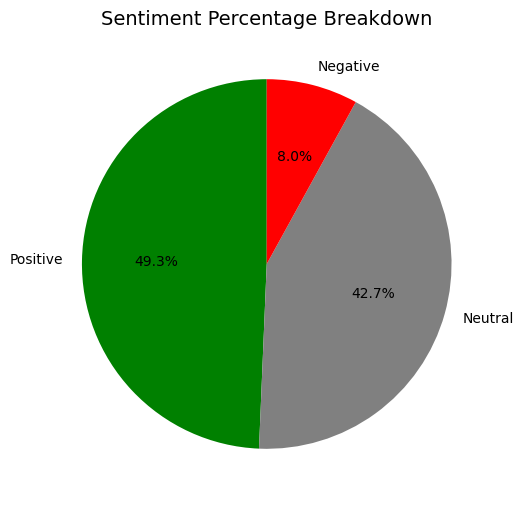

In [ ]:
df["sentiment"].value_counts().plot(
    kind = "pie",
    autopct = '%1.1f%%',
    figsize=(6, 6),
    colors=['green', 'gray', 'red'],
    startangle=90
)

plt.title("Sentiment Percentage Breakdown", fontsize=14)
plt.ylabel("")
plt.show()

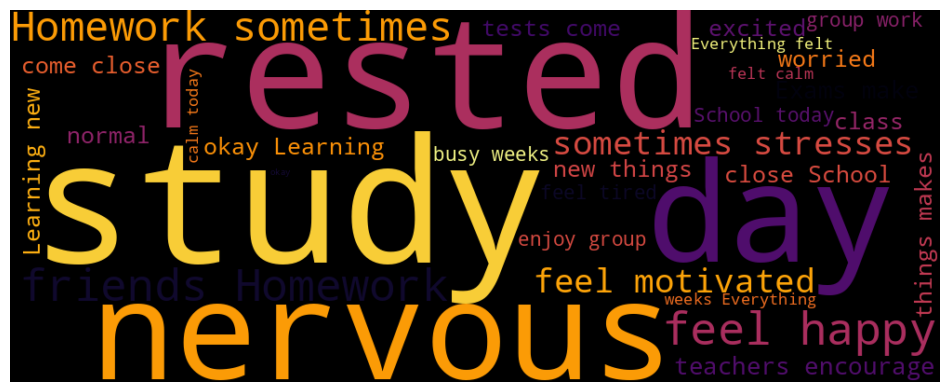

In [ ]:
text_all = " ".join(df["reflection_text"])

wc = WordCloud(
    width = 1000,
    height = 400,
    background_color="black",
    colormap="inferno"
).generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")

plt.show()

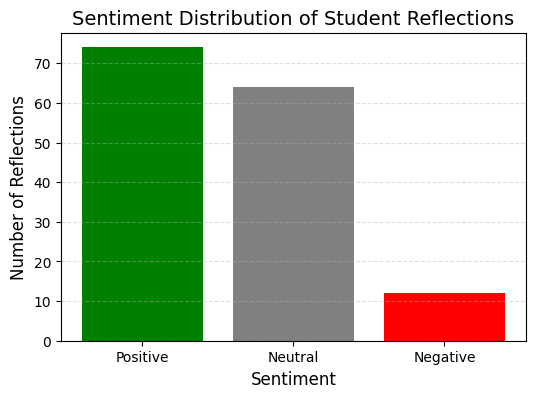

In [ ]:
import matplotlib.pyplot as plt

# Make sure the order is correct
order = ["Positive", "Neutral", "Negative"]
colors = ["green", "gray", "red"]

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(order, sentiment_counts[order], color=colors)

plt.title("Sentiment Distribution of Student Reflections", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Number of Reflections", fontsize=12)
plt.grid(axis='y', linestyle = '--', alpha=0.4)
